In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\Yashita_Project_Folder\Instacart_darkstore_analysis\orders.csv')
order_products = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\Yashita_Project_Folder\Instacart_darkstore_analysis\order_products__prior.csv')
products = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\Yashita_Project_Folder\Instacart_darkstore_analysis\products.csv')
aisles = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\Yashita_Project_Folder\Instacart_darkstore_analysis\aisles.csv')
departments = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\Yashita_Project_Folder\Instacart_darkstore_analysis\departments.csv')

In [3]:
df = (
    order_products
    .merge(orders, on="order_id")
    .merge(products, on="product_id")
    .merge(aisles, on="aisle_id")
    .merge(departments, on="department_id")
)

In [4]:
df.head(10)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,26,33120,5,0,153404,prior,2,0,16,7.0,Organic Egg Whites,86,16,eggs,dairy eggs
2,120,33120,13,0,23750,prior,11,6,8,10.0,Organic Egg Whites,86,16,eggs,dairy eggs
3,327,33120,5,1,58707,prior,21,6,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
4,390,33120,28,1,166654,prior,48,0,12,9.0,Organic Egg Whites,86,16,eggs,dairy eggs
5,537,33120,2,1,180135,prior,15,2,8,3.0,Organic Egg Whites,86,16,eggs,dairy eggs
6,582,33120,7,1,193223,prior,6,2,19,10.0,Organic Egg Whites,86,16,eggs,dairy eggs
7,608,33120,5,1,91030,prior,11,3,21,12.0,Organic Egg Whites,86,16,eggs,dairy eggs
8,623,33120,1,1,37804,prior,63,3,12,3.0,Organic Egg Whites,86,16,eggs,dairy eggs
9,689,33120,4,1,108932,prior,16,1,13,3.0,Organic Egg Whites,86,16,eggs,dairy eggs


In [5]:
import numpy as np
np.random.seed(42)
n_stores = 5
df['store_id'] = np.random.choice(range(1, n_stores + 1), size=len(df))

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [7]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32434489 entries, 0 to 32434488
Data columns (total 16 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       int64  
 3   reordered               int64  
 4   user_id                 int64  
 5   eval_set                object 
 6   order_number            int64  
 7   order_dow               int64  
 8   order_hour_of_day       int64  
 9   days_since_prior_order  float64
 10  product_name            object 
 11  aisle_id                int64  
 12  department_id           int64  
 13  aisle                   object 
 14  department              object 
 15  store_id                int32  
dtypes: float64(1), int32(1), int64(10), object(4)
memory usage: 4.0+ GB


order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
store_id                        0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing[missing > 0])

days_since_prior_order    2078068
dtype: int64


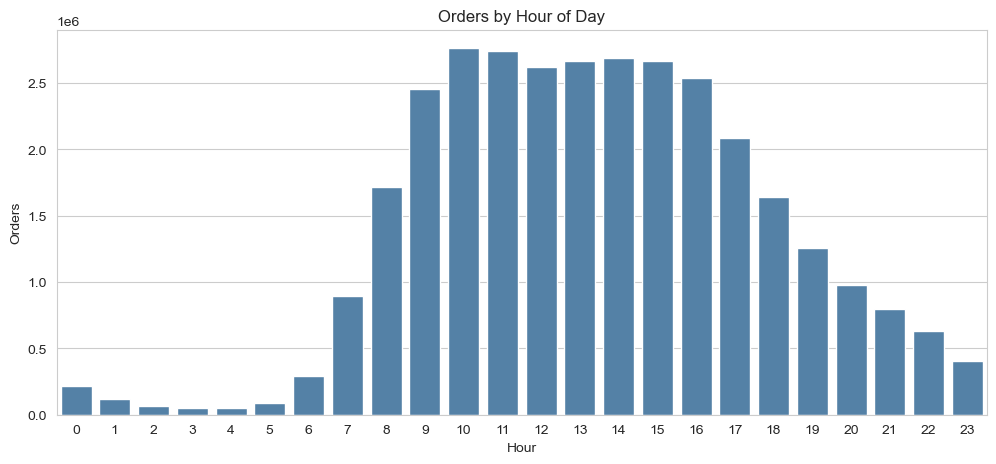

In [10]:
# order hour of the day 
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="order_hour_of_day",
    color="steelblue"
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Orders")

plt.show()

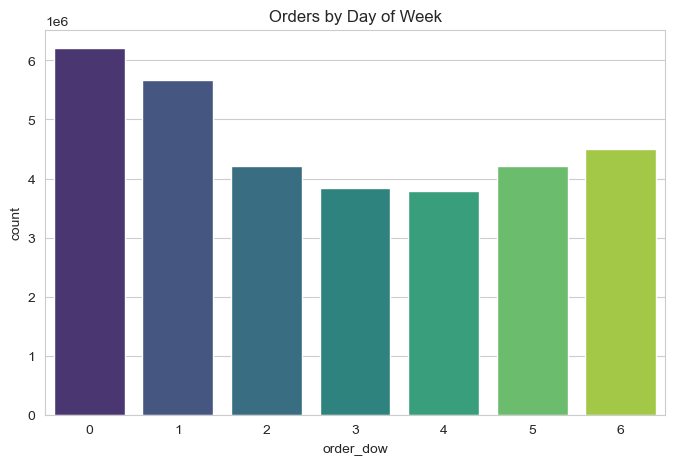

In [11]:
#order by DAY of week 
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="order_dow",
    palette="viridis"
)

plt.title("Orders by Day of Week")
plt.show()

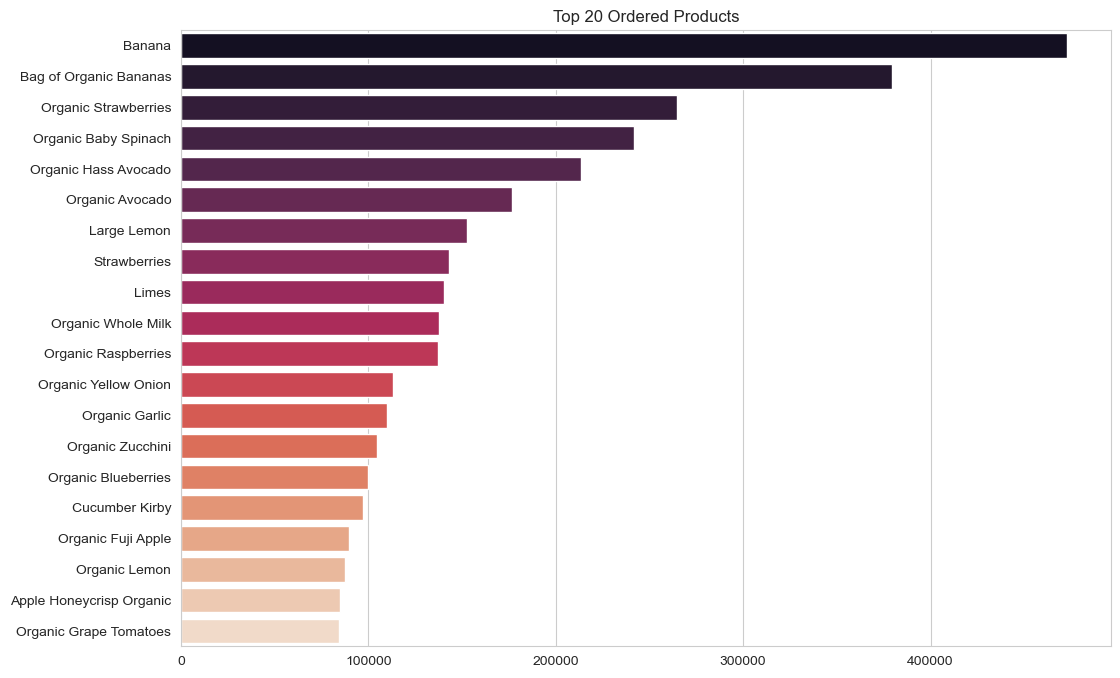

In [12]:
#top 20 orders 
top_products = (
    df["product_name"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="rocket"
)

plt.title("Top 20 Ordered Products")

plt.show()

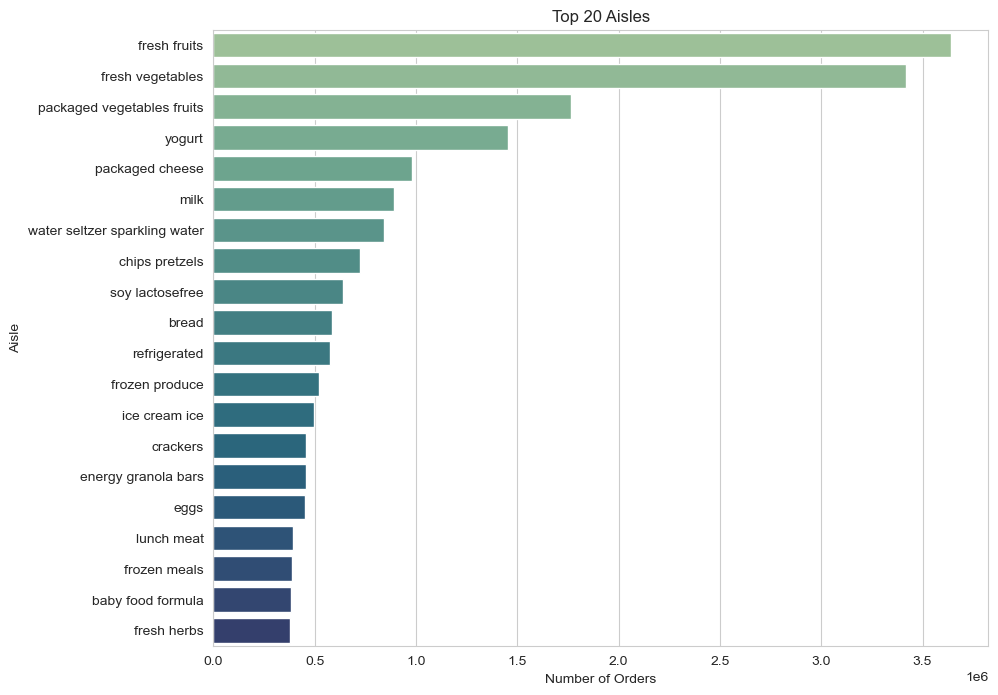

In [13]:
# Top 20 aisles
aisle = (
    df["aisle"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,8))

sns.barplot(
    x=aisle.values,
    y=aisle.index,
    palette="crest"
)

plt.title("Top 20 Aisles")
plt.xlabel("Number of Orders")
plt.ylabel("Aisle")

plt.show()

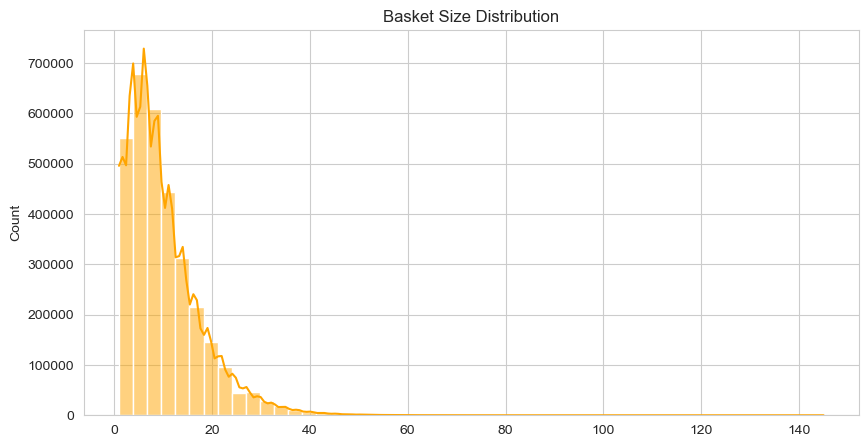

In [14]:
#basket size distribution
basket = (
    df.groupby("order_id")
    .size()
)

plt.figure(figsize=(10,5))

sns.histplot(
    basket,
    bins=50,
    kde=True,
    color="orange"
)

plt.title("Basket Size Distribution")

plt.show()

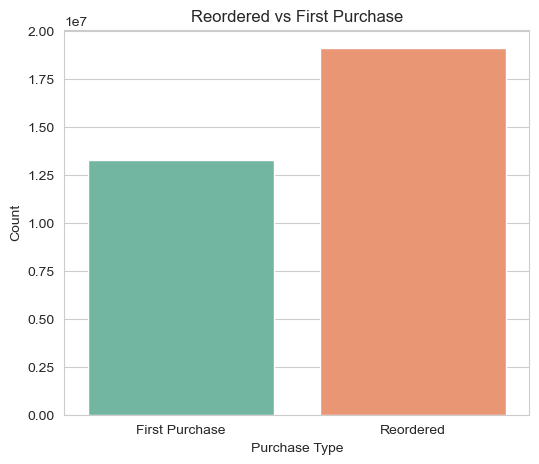

In [15]:
#reorder distribution
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="reordered",
    palette="Set2"
)

ax.set_xticklabels(["First Purchase", "Reordered"])

plt.title("Reordered vs First Purchase")
plt.xlabel("Purchase Type")
plt.ylabel("Count")

plt.show()

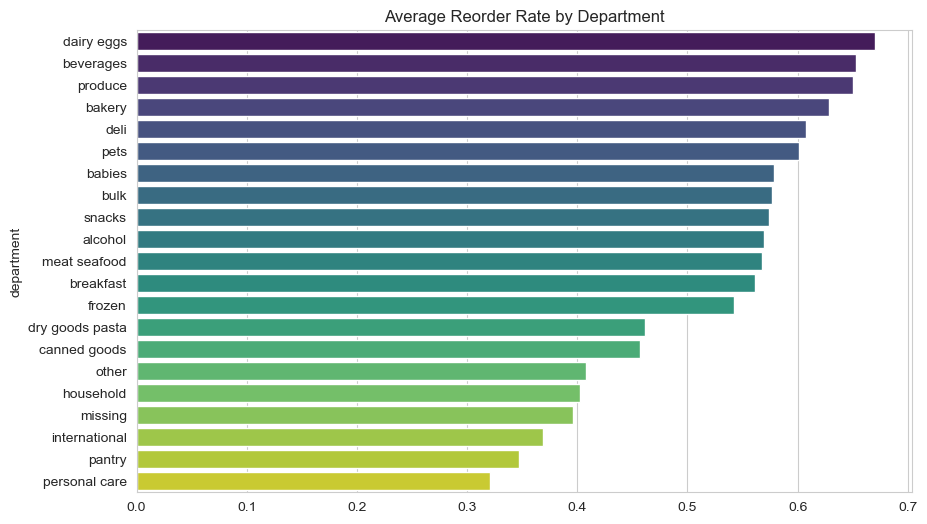

In [16]:
#average reorder  rate by department
reorder = (
    df.groupby("department")["reordered"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=reorder.values,
    y=reorder.index,
    palette="viridis"
)

plt.title("Average Reorder Rate by Department")

plt.show() 

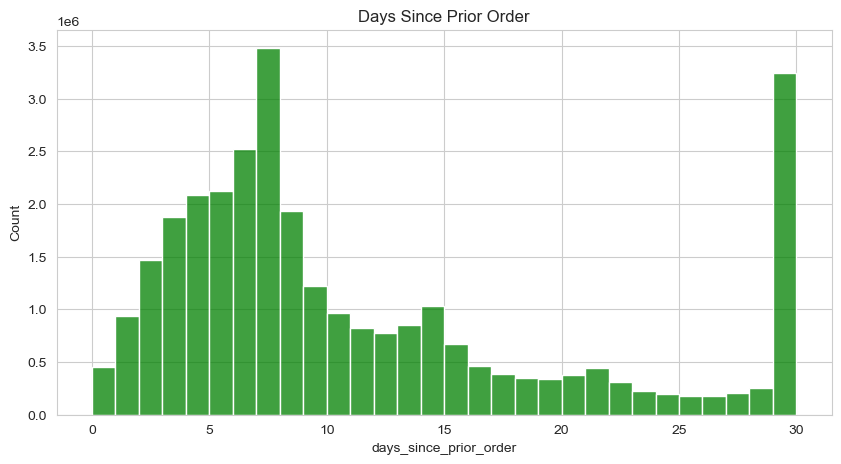

In [17]:
#days since prior order 
plt.figure(figsize=(10,5))

sns.histplot(
    df["days_since_prior_order"],
    bins=30,
    color="green"
)

plt.title("Days Since Prior Order")
plt.show()

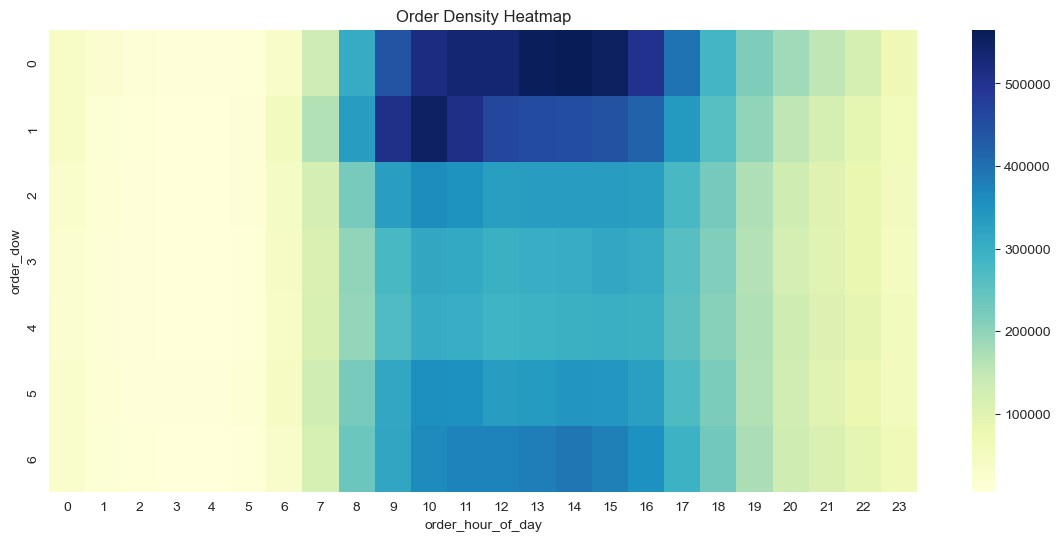

In [18]:
heat = (
    df.pivot_table(
        index="order_dow",
        columns="order_hour_of_day",
        values="order_id",
        aggfunc="count"
    )
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heat,
    cmap="YlGnBu"
)

plt.title("Order Density Heatmap")

plt.show()

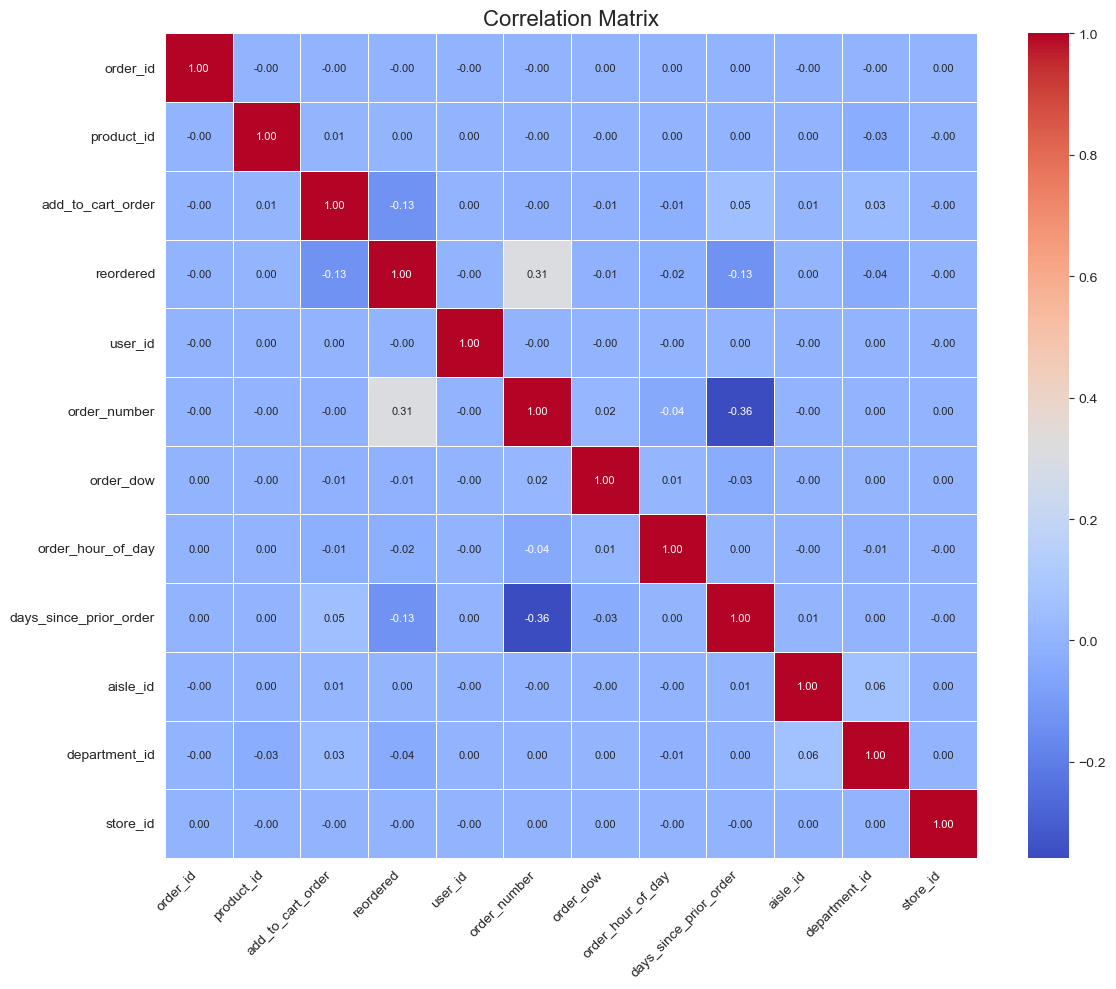

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",          # Show 2 decimal places
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 8}   # Smaller annotation text
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

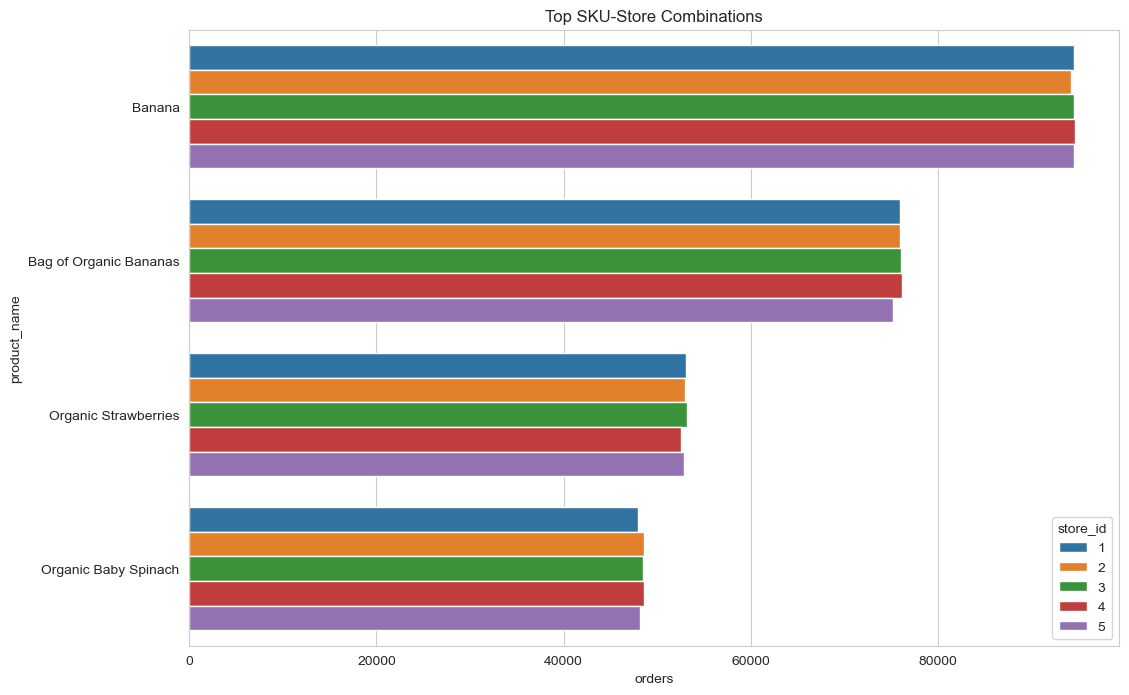

In [20]:
#SKU STORE DEMAND 
sku_store = (
    df.groupby(["store_id","product_name"])
    .size()
    .reset_index(name="orders")
)

top = sku_store.nlargest(20,"orders")

plt.figure(figsize=(12,8))

sns.barplot(
    data=top,
    x="orders",
    y="product_name",
    hue="store_id"
)

plt.title("Top SKU-Store Combinations")

plt.show()

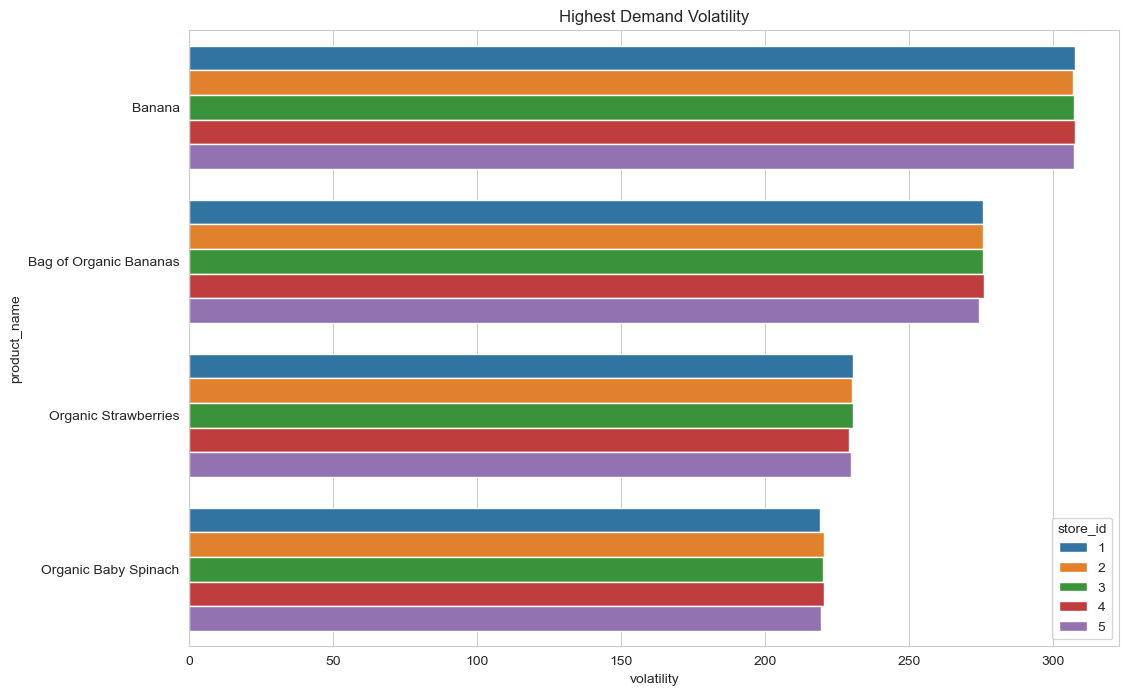

In [21]:
#DEMAND VOLATILITY 
volatility = (
    df.groupby(["store_id","product_name"])
    .size()
    .reset_index(name="orders")
)

volatility["volatility"] = np.sqrt(volatility["orders"])

top_volatility = volatility.nlargest(20,"volatility")

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_volatility,
    x="volatility",
    y="product_name",
    hue="store_id"
)

plt.title("Highest Demand Volatility")

plt.show()

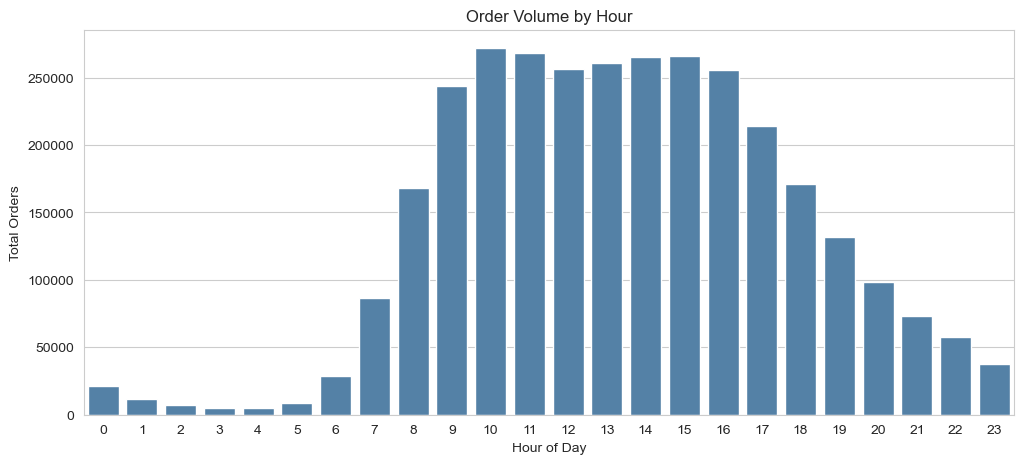

In [22]:
# what are peak shopping hours 
#At what hours do customers place the highest number of orders so that we can optimize staffing and inventory availability?
orders_per_hour = (
    df.groupby("order_hour_of_day")["order_id"]
      .nunique()
      .reset_index(name="total_orders")
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=orders_per_hour,
    x="order_hour_of_day",
    y="total_orders",
    color="steelblue"
)

plt.title("Order Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Orders")

plt.show()

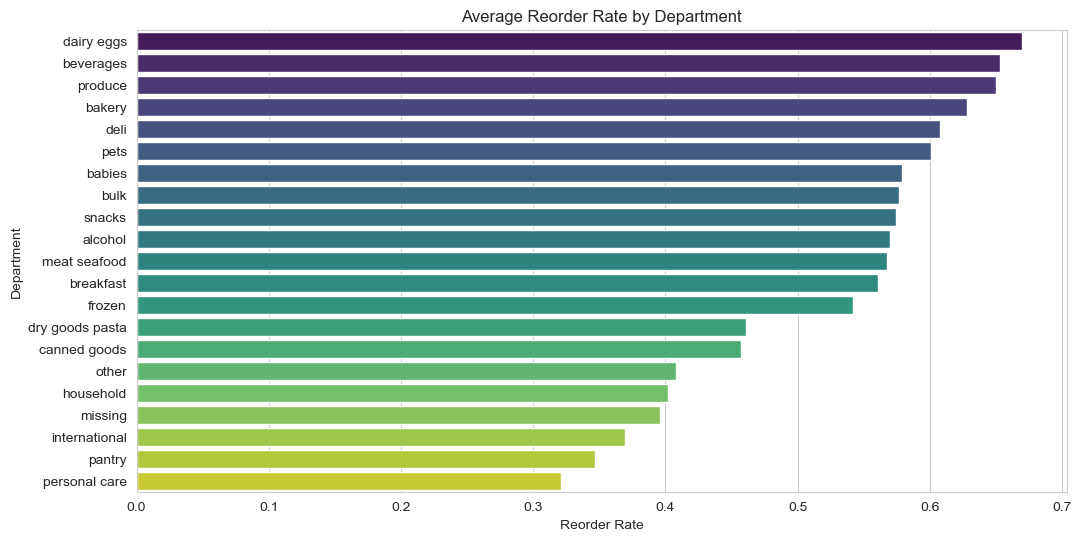

In [23]:
#Which departments drive the highest repeat purchases?
#Which product categories have the highest customer loyalty?
reorder = (
    df.groupby("department")["reordered"]
      .mean()
      .reset_index()
      .sort_values("reordered", ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=reorder,
    x="reordered",
    y="department",
    palette="viridis"
)

plt.title("Average Reorder Rate by Department")

plt.xlabel("Reorder Rate")
plt.ylabel("Department")

plt.show()

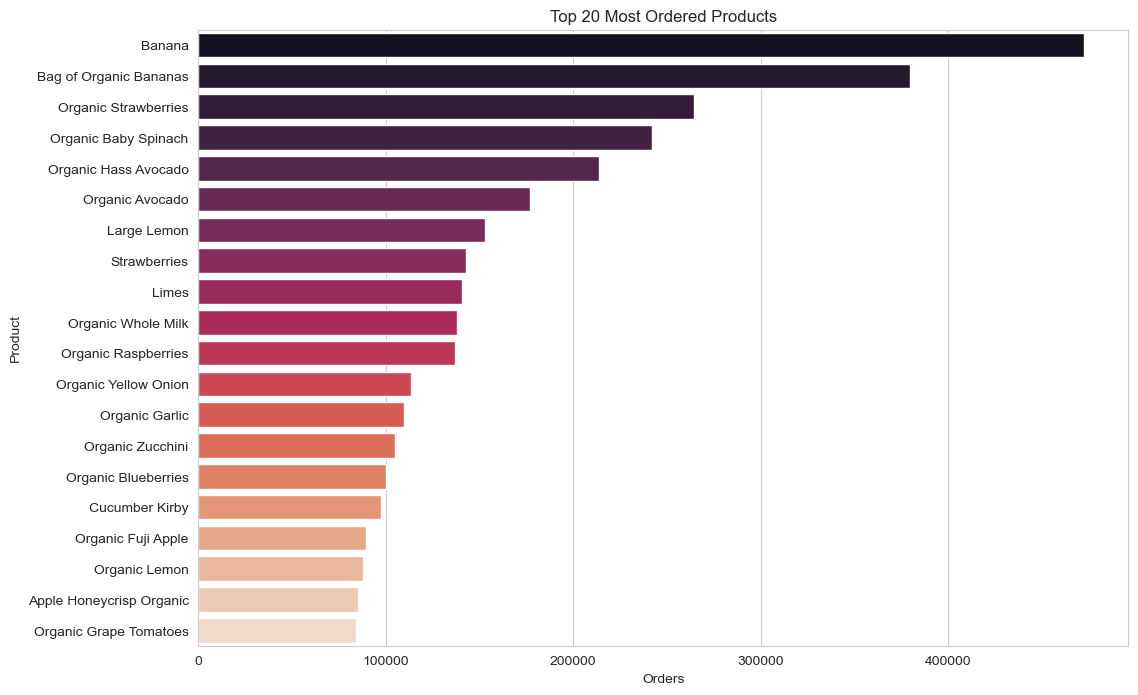

In [24]:
#Which products generate the highest demand?
#Which products should always remain in stock?
top_products = (
    df.groupby("product_name")
      .size()
      .reset_index(name="orders")
      .sort_values("orders", ascending=False)
      .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_products,
    x="orders",
    y="product_name",
    palette="rocket"
)

plt.title("Top 20 Most Ordered Products")

plt.xlabel("Orders")
plt.ylabel("Product")

plt.show()

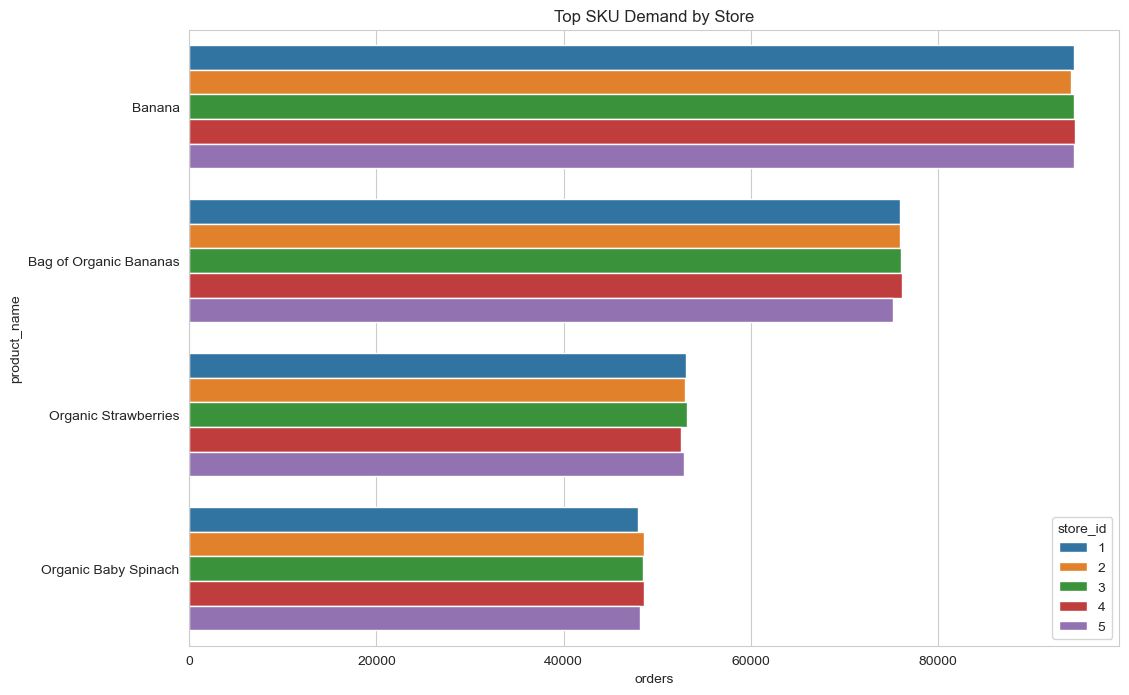

In [25]:
#: Which Store–SKU combinations should be prioritized for forecasting?
sku_store = (
    df.groupby(["store_id","product_name"])
      .size()
      .reset_index(name="orders")
)

top20 = sku_store.nlargest(20,"orders")

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x="orders",
    y="product_name",
    hue="store_id"
)

plt.title("Top SKU Demand by Store")

plt.show()

In [26]:
#creating time series data 
#synthetic order date

orders = orders.sort_values(["user_id", "order_number"])

orders["days_since_prior_order"] = (
    orders["days_since_prior_order"]
    .fillna(0)
)

orders["synthetic_day"] = (
    orders.groupby("user_id")["days_since_prior_order"]
    .cumsum()
)

In [27]:
#choose a reference date
orders["order_date"] = (
    pd.Timestamp("2023-01-01")
    + pd.to_timedelta(orders["synthetic_day"], unit="D")
)

In [28]:
#merge with product level data 
df = (
    order_products
    .merge(orders, on="order_id")
    .merge(products, on="product_id")
    .merge(aisles, on="aisle_id")
    .merge(departments, on="department_id")
)

In [30]:
#demand table filled
daily_demand = (
    df.groupby(
        [ "product_id", "order_date"]
    )
    .size()
    .reset_index(name="units_sold")
)

daily_demand.head()

,product_id,order_date,units_sold
0,1,2023-01-01,103
1,1,2023-01-02,1
2,1,2023-01-03,4
3,1,2023-01-04,5
4,1,2023-01-05,2


In [31]:
#flling missing value 
full_index = pd.MultiIndex.from_product(
    [
        daily_demand["product_id"].unique(),
        pd.date_range(
            daily_demand["order_date"].min(),
            daily_demand["order_date"].max(),
            freq="D",
        ),
    ],
    names=[ "product_id", "order_date"],
)

daily_demand = (
    daily_demand
    .set_index([ "product_id", "order_date"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

In [32]:
#saving the file 
daily_demand.to_csv(
    r"C:\Users\user\OneDrive\Desktop\Yashita_Project_Folder\Instacart_darkstore_analysis\daily_demand1.csv",
    index=False
)

In [33]:
import sys
!{sys.executable} -m pip show xgboost

Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: c:\users\user\anaconda3\lib\site-packages
Requires: numpy, scipy
Required-by: 


In [34]:
import sys
print(sys.executable)

c:\Users\user\anaconda3\python.exe


In [35]:
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split


In [36]:
df_feat = daily_demand.copy()

In [37]:
df_feat["dayofweek"] = df_feat["order_date"].dt.dayofweek
df_feat["month"] = df_feat["order_date"].dt.month
df_feat["week"] = df_feat["order_date"].dt.isocalendar().week.astype(int)
df_feat["dayofyear"] = df_feat["order_date"].dt.dayofyear

In [38]:
df_feat["lag_1"] = df_feat.groupby(
    ["product_id"]
)["units_sold"].shift(1)

df_feat["lag_3"] = df_feat.groupby(
    ["product_id"]
)["units_sold"].shift(3)

df_feat["lag_7"] = df_feat.groupby(
    ["product_id"]
)["units_sold"].shift(7)

df_feat["lag_14"] = df_feat.groupby(
    ["product_id"]
)["units_sold"].shift(14)

In [39]:
df_feat["rolling_mean_7"] = (
    df_feat.groupby(["product_id"])["units_sold"]
           .transform(lambda x: x.rolling(7).mean())
)

df_feat["rolling_mean_14"] = (
    df_feat.groupby(["product_id"])["units_sold"]
           .transform(lambda x: x.rolling(14).mean())
)

df_feat["rolling_std_7"] = (
    df_feat.groupby(["product_id"])["units_sold"]
           .transform(lambda x: x.rolling(7).std())
)

In [40]:
X = df_feat[
[
"product_id",
"dayofweek",
"month",
"week",
"dayofyear",
"lag_1",
"lag_3",
"lag_7",
"lag_14",
"rolling_mean_7",
"rolling_mean_14",
"rolling_std_7"
]
]

In [41]:
y = df_feat['units_sold']

In [42]:
# time-based split, NOT random — this matters for forecasting credibility

split_date = df_feat['order_date'].quantile(0.8)

train = df_feat[df_feat['order_date'] <= split_date]

test = df_feat[df_feat['order_date'] > split_date]


In [43]:

import numpy as np

In [44]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [45]:
model.fit(train[X.columns], train['units_sold'])

preds = model.predict(test[X.columns])



In [46]:
print("Train:", train.shape)
print("Test :", test.shape)
print("X     :", X.shape)
print("Train columns:", len(train.columns))
print("X columns:", len(X.columns))
print(train.columns.duplicated().sum())
print(set(X.columns) - set(train.columns))

Train: (14555361, 14)
Test : (3626421, 14)
X     : (18181782, 12)
Train columns: 14
X columns: 12
0
set()


In [47]:
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_absolute_error
)


mape = mean_absolute_percentage_error(
    test["units_sold"] + 1,
    preds + 1
)

rmse = np.sqrt(
    mean_squared_error(
        test["units_sold"],
        preds
    )
)

mae = mean_absolute_error(
    test["units_sold"],
    preds
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")

MAE : 0.55
RMSE: 1.98
MAPE: 40.90%


In [48]:
daily_demand["units_sold"].describe()

count    1.818178e+07
mean     1.783900e+00
std      2.097431e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      2.977600e+04
Name: units_sold, dtype: float64

In [50]:
top_series = (
    daily_demand.groupby([ "product_id"])["units_sold"]
    .sum()
    .reset_index()
    .sort_values("units_sold", ascending=False)
    .head(20)
)

top_series

,product_id,units_sold
24848,24852,472565
13172,13176,379450
21133,21137,264683
21899,21903,241921
47198,47209,213584
47755,47766,176815
47615,47626,152657
16793,16797,142951
26204,26209,140627
27839,27845,137905


In [51]:
top_product = top_series.iloc[0]["product_id"]

print(top_product)

24852


In [52]:
series = (
    daily_demand[daily_demand["product_id"] == top_product]
    .sort_values("order_date")
)

series = series["units_sold"].values

print(series.shape)

(366,)


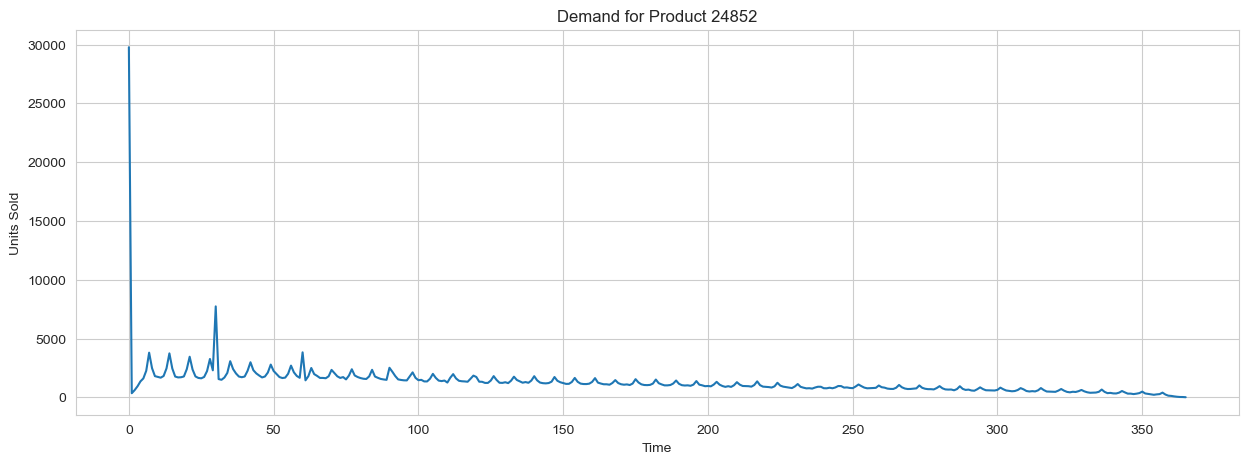

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(series)

plt.title(f"Demand for Product {top_product}")

plt.xlabel("Time")

plt.ylabel("Units Sold")

plt.show()

In [54]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

series_scaled = scaler.fit_transform(
    series.reshape(-1,1)
)

In [55]:
def create_sequences(series, window=14):

    X = []
    y = []

    for i in range(len(series)-window):

        X.append(series[i:i+window])

        y.append(series[i+window])

    return np.array(X), np.array(y)

In [56]:
X, y = create_sequences(series_scaled, window=14)

print(X.shape)
print(y.shape)

(352, 14, 1)
(352, 1)


In [57]:
print(top_product)
print(series.shape)
print(X.shape)
print(y.shape)

24852
(366,)
(352, 14, 1)
(352, 1)


In [59]:
#train and split the data 
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(281, 14, 1)
(71, 14, 1)


In [60]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [61]:
import torch.nn as nn

class DemandLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        out = self.fc(out[:,-1,:])

        return out

In [62]:
model = DemandLSTM()

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [63]:
epochs = 50

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    pred = model(X_train)

    loss = loss_fn(pred,y_train)

    loss.backward()

    optimizer.step()

    if (epoch+1)%10==0:

        print(
            f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}"
        )

Epoch 10/50 | Loss: 0.0006
Epoch 20/50 | Loss: 0.0005
Epoch 30/50 | Loss: 0.0005
Epoch 40/50 | Loss: 0.0005
Epoch 50/50 | Loss: 0.0005


In [64]:
model.eval()

with torch.no_grad():

    preds = model(X_test)

preds = preds.numpy()

In [65]:
preds = scaler.inverse_transform(preds)

actual = scaler.inverse_transform(y_test.numpy())

In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(actual, preds)

rmse = np.sqrt(
    mean_squared_error(actual, preds)
)

mape = mean_absolute_percentage_error(
    actual + 1,
    preds + 1
)

r2 = r2_score(actual, preds)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2%}")
print(f"R²   : {r2:.4f}")

MAE  : 966.17
RMSE : 983.73
MAPE : 688.00%
R²   : -27.1996


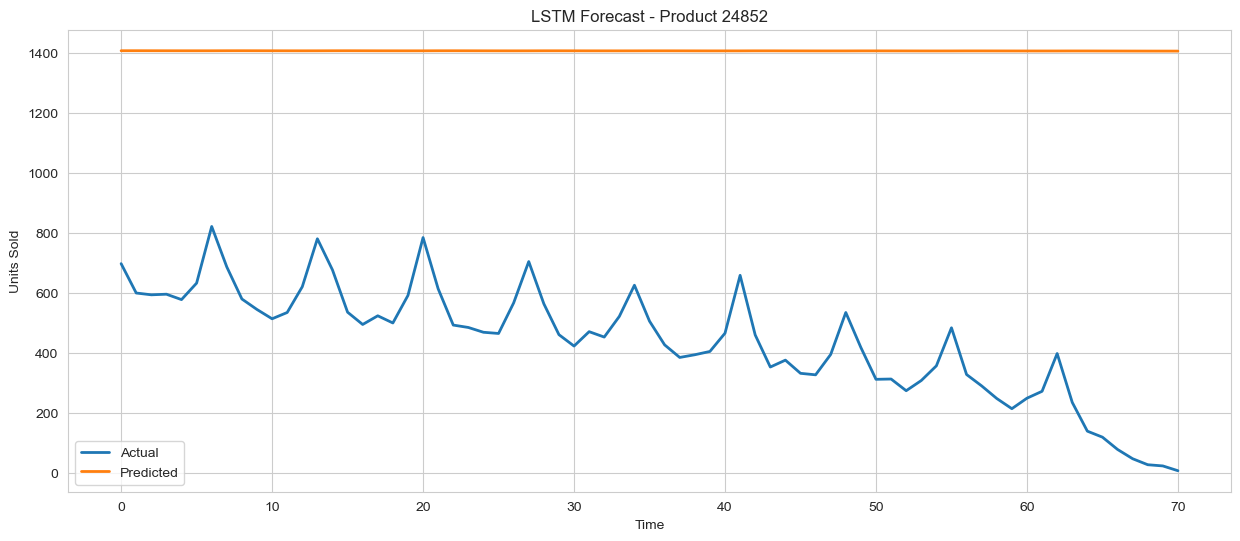

In [67]:
plt.figure(figsize=(15,6))

plt.plot(
    actual,
    label="Actual",
    linewidth=2
)

plt.plot(
    preds,
    label="Predicted",
    linewidth=2
)

plt.title(f"LSTM Forecast - Product {top_product}")

plt.xlabel("Time")

plt.ylabel("Units Sold")

plt.legend()

plt.show()

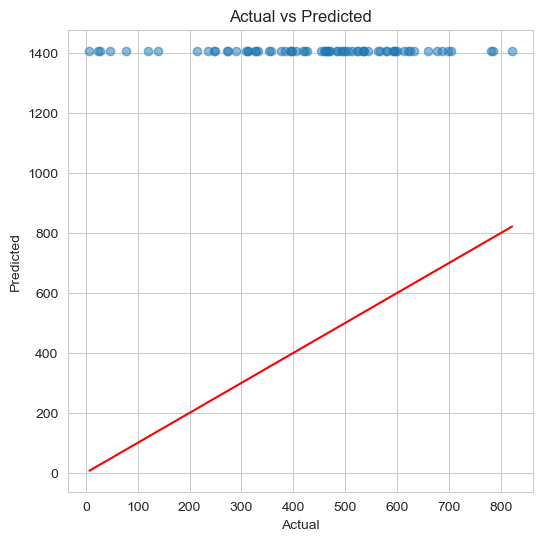

In [69]:
plt.figure(figsize=(6,6))

plt.scatter(actual, preds, alpha=0.5)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.plot(
    [actual.min(), actual.max()],
    [actual.min(), actual.max()],
    color="red"
)

plt.show()

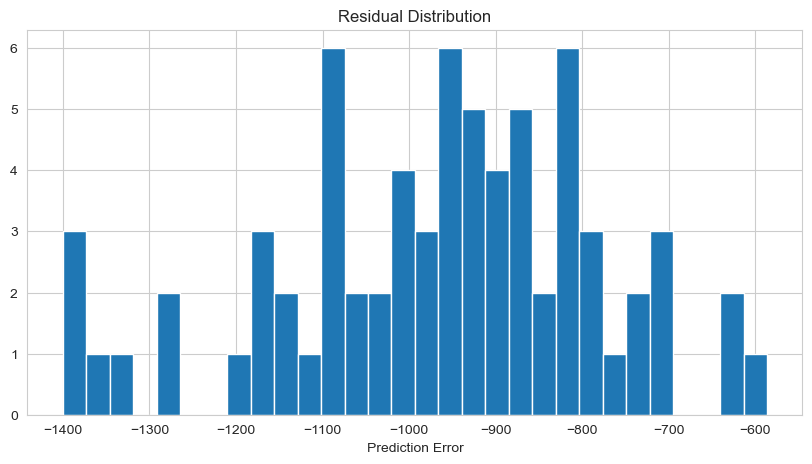

In [70]:
residuals = actual.flatten() - preds.flatten()

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=30
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

In [71]:
comparison = {
    "Model":["XGBoost","LSTM"],
    "MAE":[0.55, mae],
    "RMSE":[1.98, rmse],
    "MAPE":[40.90, mape*100]
}

comparison = pd.DataFrame(comparison)

comparison

,Model,MAE,RMSE,MAPE
0,XGBoost,0.55000,1.980000,40.900000
1,LSTM,966.17395,983.726257,687.997293


In [73]:
print(series[:20])
print(actual[:10].flatten())
print(preds[:10].flatten())
print(series.min(), series.max())

[29776   347   613   941  1353  1605  2259  3798  2480  1801  1732  1669
  1813  2461  3738  2449  1765  1692  1705  1772]
[698. 600. 594. 596. 578. 633. 822. 687. 580. 545.]
[1408.4647 1408.4908 1408.4198 1408.3495 1408.3041 1408.2672 1408.281
 1408.4233 1408.4547 1408.3848]
7 29776


In [74]:
daily_demand[
    daily_demand["product_id"] == 24852
].head(20)

,product_id,order_date,units_sold
9094368,24852,2023-01-01,29776
9094369,24852,2023-01-02,347
9094370,24852,2023-01-03,613
9094371,24852,2023-01-04,941
9094372,24852,2023-01-05,1353
9094373,24852,2023-01-06,1605
9094374,24852,2023-01-07,2259
9094375,24852,2023-01-08,3798
9094376,24852,2023-01-09,2480
9094377,24852,2023-01-10,1801
